In [2]:
# ============================================
# 1. Imports
# ============================================
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from prophet import Prophet
from xgboost import XGBRegressor
import holidays

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


# ============================================
# 2. Warning/settings
# ============================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
np.random.seed(42)
tf.random.set_seed(42)

MODEL_DIR = Path("final_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# ============================================
# 3. Helper functions
# ============================================
def mae_rmse(y_true, y_pred, label):
    y_true = pd.Series(y_true).astype("float64")
    y_pred = pd.Series(y_pred, index=y_true.index).astype("float64")

    mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
    y_true = y_true.loc[mask]
    y_pred = y_pred.loc[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label} : MAE: {mae:.2f} | RMSE: {rmse:.2f}")
    return mae, rmse


def print_metrics(y_true, y_pred, label="Model"):
    y_true = pd.Series(y_true).astype("float64")
    y_pred = pd.Series(y_pred, index=y_true.index).astype("float64")

    mask = (~pd.isna(y_true)) & (~pd.isna(y_pred))
    y_true = y_true.loc[mask]
    y_pred = y_pred.loc[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    avg = float(y_true.mean())

    print(f"\n{label} (Test: 2024)")
    print(f"MAE  : {mae:.2f} MW  ({mae / avg * 100:.2f}% of mean load)")
    print(f"RMSE : {rmse:.2f} MW  ({rmse / avg * 100:.2f}% of mean load)")
    print(f"Mean load : {avg:.2f} MW")
    return mae, rmse


def adf_kpss(series, name):
    s = pd.Series(series).dropna().astype("float64")
    adf_p = adfuller(s)[1]
    kpss_p = kpss(s, regression="c")[1]
    print(f"{name} | ADF p={adf_p:.6f} | KPSS p={kpss_p:.6f}")


def build_features_xgb(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    d["hour_sin"] = np.sin(2 * np.pi * d.index.hour / 24)
    d["hour_cos"] = np.cos(2 * np.pi * d.index.hour / 24)
    d["dow_sin"] = np.sin(2 * np.pi * d.index.dayofweek / 7)
    d["dow_cos"] = np.cos(2 * np.pi * d.index.dayofweek / 7)
    d["month_sin"] = np.sin(2 * np.pi * d.index.month / 12)
    d["month_cos"] = np.cos(2 * np.pi * d.index.month / 12)
    d["dayofyear"] = d.index.dayofyear
    d["is_weekend"] = (d.index.dayofweek >= 5).astype(int)

    ab_holidays = holidays.Canada(prov="AB", years=range(2013, 2025))
    ab_holiday_dates = set(pd.to_datetime(list(ab_holidays.keys())).normalize())
    d["is_holiday"] = d.index.normalize().isin(ab_holiday_dates).astype(int)

    for L in [2, 3, 24, 48, 72, 168, 336]:
        d[f"lag_{L}"] = d["TOTAL_LOAD"].shift(L)

    load_s1 = d["TOTAL_LOAD"].shift(1)
    d["roll_mean_24"] = load_s1.rolling(24).mean()
    d["roll_mean_168"] = load_s1.rolling(168).mean()
    d["roll_mean_336"] = load_s1.rolling(336).mean()
    d["roll_mean_720"] = load_s1.rolling(720).mean()
    d["roll_std_24"] = load_s1.rolling(24).std()
    d["roll_std_168"] = load_s1.rolling(168).std()

    temp_s1 = d["temperature"].shift(1)
    d["temp_lag1"] = temp_s1
    d["temp_lag24"] = d["temperature"].shift(24)
    d["temp_roll_mean_24"] = temp_s1.rolling(24).mean()
    d["temp_roll_std_24"] = temp_s1.rolling(24).std()

    d["y"] = d["TOTAL_LOAD"]
    return d


def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X.iloc[i - seq_len:i].values)
        ys.append(y.iloc[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

In [ ]:
# ============================================
# 4. Load and clean data
# ============================================
from pathlib import Path

DATA_PATH = Path("../data/sample/AESO_Load_2013_2024_ML_Ready_sample.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data file not found: {DATA_PATH}\n"
        "Download the AESO source data, prepare the ML-ready file, "
        "and place a sample version in data/sample/ before running this notebook."
    )

df = pd.read_csv(DATA_PATH)

df["DT_MST"] = pd.to_datetime(df["DT_MST"], errors="coerce")
df = df.dropna(subset=["DT_MST"]).set_index("DT_MST").sort_index().asfreq("H")

df["TOTAL_LOAD"] = df["TOTAL_LOAD"].interpolate("time").ffill().bfill()

df["temperature"] = df["temperature"].interpolate("time").ffill().bfill()


In [4]:
# ============================================
# 5. Train/test split
# ============================================
train = df.loc["2013-01-01":"2023-12-31 23:00"].copy()
test = df.loc["2024-01-01":"2024-12-31 23:00"].copy()

y_train = train["TOTAL_LOAD"]
y_test = test["TOTAL_LOAD"]

print(f"Train size: {len(train)} hours | Test size: {len(test)} hours")

Train size: 96408 hours | Test size: 8784 hours


In [5]:
# ============================================
# 6. Stationarity checks
# ============================================
print("\nSTATIONARITY TESTS (TRAIN ONLY)")
adf_kpss(y_train, "RAW")
adf_kpss(y_train.diff(), "DIFF(1)")
adf_kpss(y_train.diff(24), "DIFF(24)")
adf_kpss(y_train.diff(168), "DIFF(168)")



STATIONARITY TESTS (TRAIN ONLY)
RAW | ADF p=0.007052 | KPSS p=0.010000
DIFF(1) | ADF p=0.000000 | KPSS p=0.100000
DIFF(24) | ADF p=0.000000 | KPSS p=0.100000
DIFF(168) | ADF p=0.000000 | KPSS p=0.100000


## Stationarity Tests Interpretation:

From the stationarity tests, I observed conflicting results for the raw series. The ADF test suggested stationarity (p < 0.05), while the KPSS test indicated non-stationarity (p < 0.05). This mismatch suggests that the data still contains underlying trends or seasonal patterns, which is expected for electricity load.

After applying differencing at lag 1, 24, and 168, both tests aligned — ADF showed strong stationarity (p ≈ 0) and KPSS failed to reject stationarity (p > 0.05). This confirms that differencing successfully removed the non-stationary components.

The results also reinforce that the series has strong daily (24-hour) and weekly (168-hour) seasonality, which is important for model selection. Based on this, using differencing in ARIMA-type models is appropriate for this dataset.

In [6]:
# ============================================
# 7. Baseline models
# ============================================
print("\nBASELINE RESULTS (Test: 2024)")

sma = df["TOTAL_LOAD"].rolling(window=168, min_periods=168).mean().shift(1)
cma = df["TOTAL_LOAD"].expanding(min_periods=24).mean().shift(1)
ewma = df["TOTAL_LOAD"].ewm(span=24, adjust=False).mean().shift(1)

sma_mae, sma_rmse = mae_rmse(y_test, sma.loc[y_test.index], "SMA (168)")
cma_mae, cma_rmse = mae_rmse(y_test, cma.loc[y_test.index], "CMA")
ewma_mae, ewma_rmse = mae_rmse(y_test, ewma.loc[y_test.index], "EWMA (24)")



BASELINE RESULTS (Test: 2024)
SMA (168) : MAE: 389.92 | RMSE: 466.66
CMA : MAE: 1333.47 | RMSE: 1452.15
EWMA (24) : MAE: 351.83 | RMSE: 412.23


## Baseline Model Interpretation:

From the baseline results, I observed that all three models have relatively high error compared to the more advanced models later in the analysis. This was expected, since these methods are simple and mainly rely on past averages rather than learning patterns from the data.

Among them, CMA performed the worst because it smooths the data too much and cannot respond to short-term changes in electricity demand. SMA (168) performs slightly better since it captures weekly seasonality, but it still reacts slowly to recent changes. EWMA (24) gives more importance to recent observations, which is why it performs the best among the baseline models.

However, all baseline approaches are limited because they cannot capture more complex patterns, such as nonlinear relationships or the impact of external variables like temperature. This shows the need for more advanced models in this problem.

In [7]:
# ============================================
# 8. AR model
# ============================================
print("\nAR RESULTS")
ar_model = AutoReg(y_train.astype("float32"), lags=168, old_names=False).fit()

ar_pred = ar_model.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    dynamic=False
)
ar_pred = pd.Series(ar_pred, index=y_test.index)
ar_mae, ar_rmse = mae_rmse(y_test, ar_pred, "AR(168)")


AR RESULTS
AR(168) : MAE: 439.76 | RMSE: 528.90


In [8]:
# ============================================
# 9. ARIMA model
# ============================================
print("\nARIMA RESULTS (Test: 2024)")
arima_model = SARIMAX(
    y_train.astype("float32"),
    order=(2, 1, 2),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, method="lbfgs", maxiter=70, low_memory=True, cov_type="none")

arima_pred = arima_model.get_forecast(steps=len(y_test)).predicted_mean
arima_pred = pd.Series(arima_pred, index=y_test.index)
arima_mae, arima_rmse = mae_rmse(y_test, arima_pred, "ARIMA(2,1,2)")


ARIMA RESULTS (Test: 2024)
ARIMA(2,1,2) : MAE: 468.12 | RMSE: 592.12


## AR  and ARIMA Model Interpretation:

From the results, I observed that the AR(168) model performs moderately well by capturing weekly seasonality using lagged values. However, its performance is still limited, which suggests that relying only on past values in a linear way is not enough to fully model electricity demand.

The ARIMA(2,1,2) model, even after applying differencing to handle non-stationarity, actually performs worse than the AR model. This indicates that while differencing helps stabilize the series, the model still does not capture important patterns like seasonality or the effect of external factors such as temperature.

Overall, both models are restricted by their linear structure. They are not flexible enough to capture the more complex and nonlinear behavior in electricity load, which leads to higher prediction error compared to the more advanced models used later.

In [9]:
# ============================================
# 10. Manual seasonal differenced SARIMA
# ============================================
print("\nMANUAL SEASONAL-DIFF SARIMA")
s = 24
df["LOAD_SDIFF_24"] = df["TOTAL_LOAD"].diff(s)

train2 = df.loc["2013-01-01":"2023-12-31 23:00"].copy()
test2 = df.loc["2024-01-01":"2024-12-31 23:00"].copy()

y_train_sdiff = train2["LOAD_SDIFF_24"].dropna().astype("float32")
y_test_level = test2["TOTAL_LOAD"].astype("float32")

manual_sarima_model = SARIMAX(
    y_train_sdiff,
    order=(1, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, method="lbfgs", maxiter=50, low_memory=True, cov_type="none")

fc_sdiff = manual_sarima_model.get_forecast(steps=len(y_test_level)).predicted_mean
fc_sdiff = np.asarray(fc_sdiff, dtype="float64")

history = list(train2["TOTAL_LOAD"].iloc[-s:].astype("float64").values)
yhat = np.empty(len(y_test_level), dtype="float64")
for i in range(len(y_test_level)):
    yhat[i] = fc_sdiff[i] + history[i]
    history.append(yhat[i])

sarima_manual_pred = pd.Series(yhat, index=y_test_level.index)
sarima_manual_mae, sarima_manual_rmse = mae_rmse(
    y_test_level, sarima_manual_pred, "Manual SDIFF(24) + ARMA(1,0,1)"
)


MANUAL SEASONAL-DIFF SARIMA
Manual SDIFF(24) + ARMA(1,0,1) : MAE: 442.27 | RMSE: 570.43


## Temperature vs Load Relationship

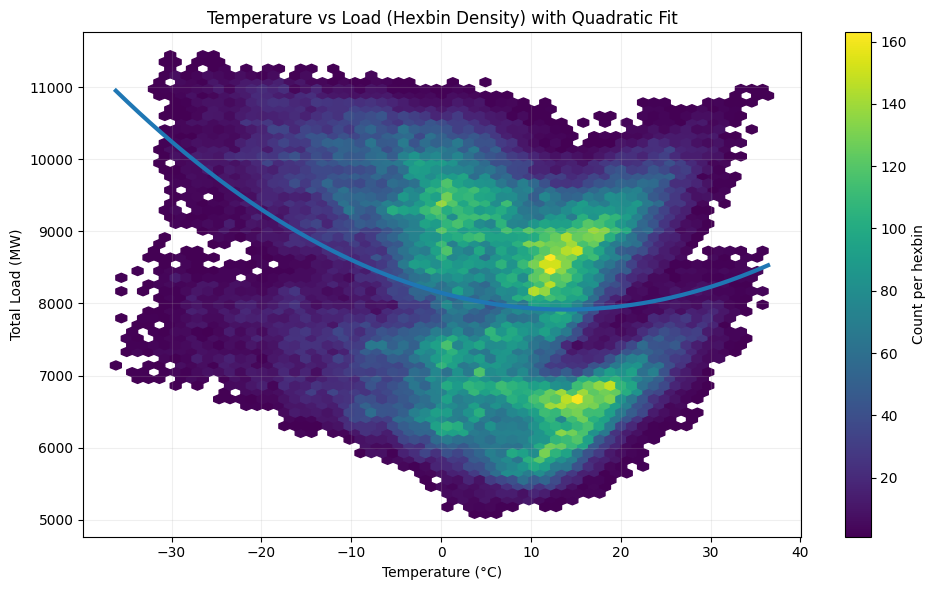

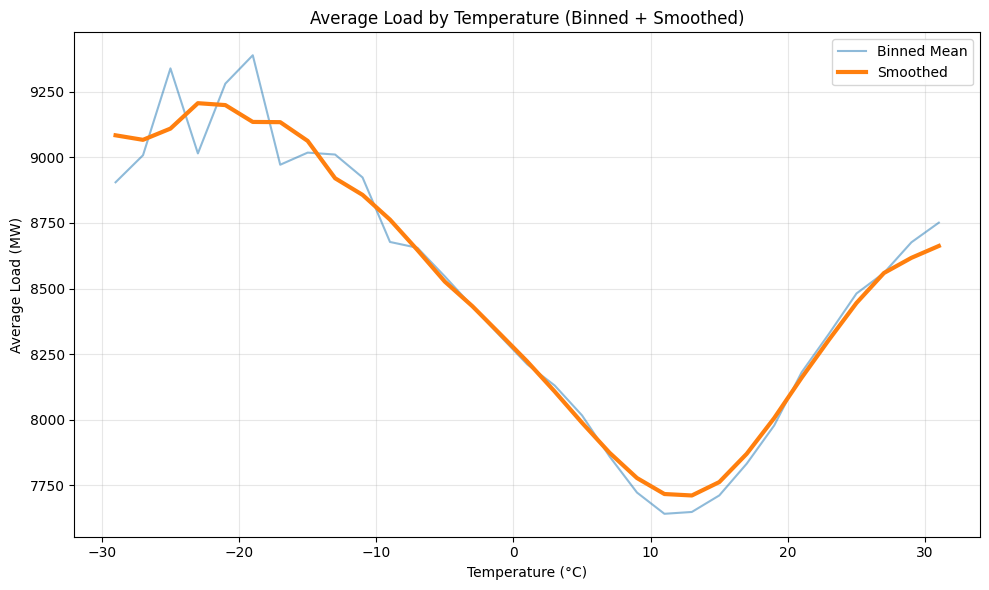

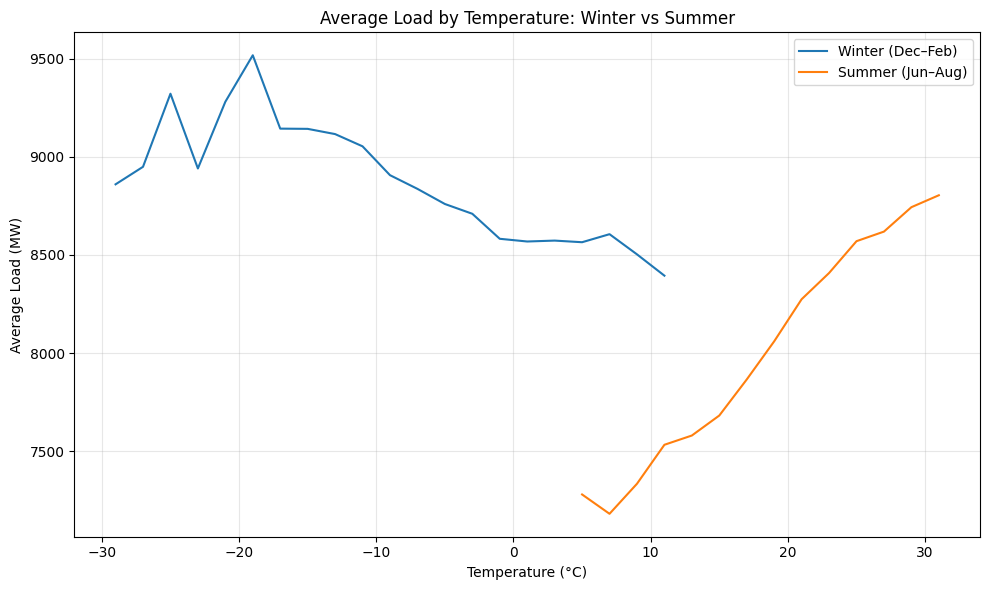

Quadratic coefficients [a, b, c]: [ 1.20978031e+00 -3.35687084e+01  8.14833940e+03]


In [4]:
# -----------------------------
d = df[["temperature", "TOTAL_LOAD"]].dropna().copy()
d = d[(d["temperature"].between(-50, 50)) & (d["TOTAL_LOAD"] > 0)]

# -----------------------------
# 1) Hexbin Density + Quadratic Fit
# -----------------------------
x = d["temperature"].to_numpy()
y = d["TOTAL_LOAD"].to_numpy()

coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)

x_line = np.linspace(d["temperature"].min(), d["temperature"].max(), 400)
y_line = poly(x_line)

plt.figure(figsize=(10, 6))
hb = plt.hexbin(d["temperature"], d["TOTAL_LOAD"], gridsize=60, mincnt=1)
plt.colorbar(hb, label="Count per hexbin")
plt.plot(x_line, y_line, linewidth=3)
plt.title("Temperature vs Load (Hexbin Density) with Quadratic Fit")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Load (MW)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Average Load by Temperature (Binned + Smoothed)
# -----------------------------
bin_width = 2
bins = np.arange(
    np.floor(d["temperature"].min() / bin_width) * bin_width,
    np.ceil(d["temperature"].max() / bin_width) * bin_width + bin_width,
    bin_width
)

d["temp_bin"] = pd.cut(d["temperature"], bins=bins, include_lowest=True)

bin_stats = (
    d.groupby("temp_bin")
     .agg(avg_load=("TOTAL_LOAD", "mean"),
          count=("TOTAL_LOAD", "size"))
     .reset_index()
)

bin_stats["bin_mid"] = bin_stats["temp_bin"].apply(lambda x: (x.left + x.right) / 2)

# drop sparse bins
min_count = 200
bin_stats = bin_stats[bin_stats["count"] >= min_count].sort_values("bin_mid")

# smooth
smooth_window = 5
bin_stats["avg_load_smooth"] = bin_stats["avg_load"].rolling(
    window=smooth_window, center=True, min_periods=1
).mean()

plt.figure(figsize=(10, 6))
plt.plot(bin_stats["bin_mid"], bin_stats["avg_load"], alpha=0.5, label="Binned Mean")
plt.plot(bin_stats["bin_mid"], bin_stats["avg_load_smooth"], linewidth=3, label="Smoothed")
plt.title("Average Load by Temperature (Binned + Smoothed)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Average Load (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Winter vs Summer
# -----------------------------
d_season = d.copy()
d_season["month"] = d_season.index.month

winter_months = [12, 1, 2]
summer_months = [6, 7, 8]

def binned_curve(df_in, bins, min_count=100):
    tmp = df_in.copy()
    tmp["temp_bin"] = pd.cut(tmp["temperature"], bins=bins, include_lowest=True)
    out = (
        tmp.groupby("temp_bin")
           .agg(avg_load=("TOTAL_LOAD", "mean"),
                count=("TOTAL_LOAD", "size"))
           .reset_index()
    )
    out["bin_mid"] = out["temp_bin"].apply(lambda x: (x.left + x.right) / 2)
    out = out[out["count"] >= min_count].sort_values("bin_mid")
    return out

winter_curve = binned_curve(d_season[d_season["month"].isin(winter_months)], bins, min_count=100)
summer_curve = binned_curve(d_season[d_season["month"].isin(summer_months)], bins, min_count=100)

plt.figure(figsize=(10, 6))
plt.plot(winter_curve["bin_mid"], winter_curve["avg_load"], label="Winter (Dec–Feb)")
plt.plot(summer_curve["bin_mid"], summer_curve["avg_load"], label="Summer (Jun–Aug)")
plt.title("Average Load by Temperature: Winter vs Summer")
plt.xlabel("Temperature (°C)")
plt.ylabel("Average Load (MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Quadratic coefficients [a, b, c]:", coeff)

Overall, I observed that electricity load is strongly related to temperature, but the relationship is not linear. Demand tends to be lower at moderate temperatures and increases when temperatures are very low or very high.

When I looked at seasonal patterns, the behavior was also different across seasons. In winter, higher load is mainly driven by heating needs, while in summer it increases due to cooling demand.

This shows that both temperature and seasonal effects play an important role in electricity demand and should be included in forecasting models.

In [10]:
# ============================================
# 11. Manual seasonal differenced SARIMAX with temperature
# ============================================
print("\nMANUAL SEASONAL-DIFF SARIMAX + TEMPERATURE")
df["TEMP_SDIFF_24"] = df["temperature"].diff(s)

train3 = df.loc["2013-01-01":"2023-12-31 23:00"].copy()
test3 = df.loc["2024-01-01":"2024-12-31 23:00"].copy()

y_train_sdiff_x = train3["LOAD_SDIFF_24"].dropna().astype("float32")
y_test_level_x = test3["TOTAL_LOAD"].astype("float32")

X_train_sx = train3.loc[y_train_sdiff_x.index, ["TEMP_SDIFF_24"]].copy().ffill().bfill()
X_test_sx = test3.loc[y_test_level_x.index, ["TEMP_SDIFF_24"]].copy().ffill().bfill()

mu = float(X_train_sx["TEMP_SDIFF_24"].mean())
sd = float(X_train_sx["TEMP_SDIFF_24"].std())
sd = sd if sd != 0 else 1.0

X_train_sx = ((X_train_sx - mu) / sd).astype("float32")
X_test_sx = ((X_test_sx - mu) / sd).astype("float32")

manual_sarimax_model = SARIMAX(
    y_train_sdiff_x,
    exog=X_train_sx,
    order=(1, 0, 1),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, method="lbfgs", maxiter=50, low_memory=True, cov_type="none")

fc_sdiff_x = manual_sarimax_model.get_forecast(steps=len(y_test_level_x), exog=X_test_sx).predicted_mean
fc_sdiff_x = np.asarray(fc_sdiff_x, dtype="float64")

history_x = list(train3["TOTAL_LOAD"].iloc[-s:].astype("float64").values)
yhat_x = np.empty(len(y_test_level_x), dtype="float64")
for i in range(len(y_test_level_x)):
    yhat_x[i] = fc_sdiff_x[i] + history_x[i]
    history_x.append(yhat_x[i])

sarimax_manual_pred = pd.Series(yhat_x, index=y_test_level_x.index)
sarimax_manual_mae, sarimax_manual_rmse = mae_rmse(
    y_test_level_x, sarimax_manual_pred, "Manual SDIFF(24) + temp + ARMA(1,0,1)"
)



MANUAL SEASONAL-DIFF SARIMAX + TEMPERATURE
Manual SDIFF(24) + temp + ARMA(1,0,1) : MAE: 441.04 | RMSE: 568.87


## SARIMA and SARIMAX Model Interpretation:

After applying seasonal differencing at lag 24, I noticed that the model was better able to capture daily patterns in electricity demand. This led to more stable predictions compared to the earlier non-seasonal models.

When I included temperature in the SARIMAX model, there was a slight improvement in performance. This suggests that temperature does have an effect on electricity demand, but within this linear framework, the impact is not very strong.

Overall, the performance of both SARIMA and SARIMAX is still quite similar to the AR-based models. This indicates that even with seasonal adjustments and external variables, these models are limited in capturing the more complex and nonlinear behavior in the data.


PROPHET + TEMPERATURE


00:16:19 - cmdstanpy - INFO - Chain [1] start processing
00:18:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet + temperature
Rows compared: 8784
MAE: 289.58 | RMSE: 380.97
Average Load (2024): 6897.37 MW
MAE: 289.58 MW | 4.2 % of average load
RMSE: 380.97 MW | 5.52 % of average load


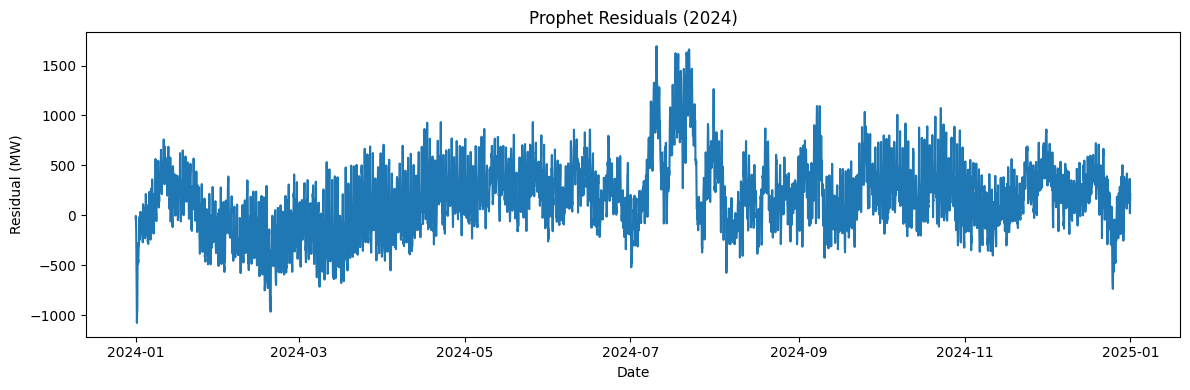

In [11]:
# ============================================
# 12. Prophet + temperature
# ============================================
print("\nPROPHET + TEMPERATURE")

prophet_df = df.reset_index().rename(columns={"DT_MST": "ds", "TOTAL_LOAD": "y"})
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], errors="coerce").dt.tz_localize(None)
prophet_df = prophet_df.dropna(subset=["ds"])
prophet_df = prophet_df[["ds", "y", "temperature"]].copy()

train_p = prophet_df[prophet_df["ds"] < "2024-01-01"].copy()
test_p = prophet_df[
    (prophet_df["ds"] >= "2024-01-01") & (prophet_df["ds"] <= "2024-12-31 23:00")
].copy()

prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.add_regressor("temperature")
prophet_model.fit(train_p)

future = prophet_model.make_future_dataframe(periods=len(test_p), freq="H")
future["ds"] = pd.to_datetime(future["ds"], errors="coerce").dt.tz_localize(None)

future = future.merge(prophet_df[["ds", "temperature"]], on="ds", how="left")
future["temperature"] = future["temperature"].interpolate().ffill().bfill()

forecast = prophet_model.predict(future)
fc = forecast[["ds", "yhat"]].copy()
pred_p = fc.merge(test_p[["ds", "y"]], on="ds", how="inner")

prophet_mae = mean_absolute_error(pred_p["y"], pred_p["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(pred_p["y"], pred_p["yhat"]))

print("Prophet + temperature")
print("Rows compared:", len(pred_p))
print("MAE:", round(prophet_mae, 2), "| RMSE:", round(prophet_rmse, 2))

avg_load = float(pred_p["y"].mean())
print("Average Load (2024):", round(avg_load, 2), "MW")
print("MAE:", round(prophet_mae, 2), "MW |", round((prophet_mae / avg_load) * 100, 2), "% of average load")
print("RMSE:", round(prophet_rmse, 2), "MW |", round((prophet_rmse / avg_load) * 100, 2), "% of average load")

residuals = pred_p["y"] - pred_p["yhat"]
plt.figure(figsize=(12, 4))
plt.plot(pred_p["ds"], residuals)
plt.title("Prophet Residuals (2024)")
plt.xlabel("Date")
plt.ylabel("Residual (MW)")
plt.tight_layout()
plt.show()


## Prophet + Temperature Model Interpretation:

From the results, I observed that the Prophet model performs reasonably well, with an MAE of 289.58 MW (about 4.2% of the average load). This indicates that it can capture the overall pattern in electricity demand fairly accurately.

Including temperature as a regressor helped improve the model, especially in capturing seasonal variations related to weather. This shows that external factors like temperature do play a role in demand forecasting.

However, when I looked at the residuals, there were noticeable errors during peak periods, particularly around times with high fluctuations. This suggests that while Prophet handles trends and seasonality well, it struggles with sudden spikes in demand.

Overall, Prophet is a reliable and easy-to-interpret model, but it is less effective compared to more flexible models when it comes to capturing extreme or highly variable demand patterns.

In [12]:
# ============================================
# 13. XGBoost feature engineering
# ============================================
feat = build_features_xgb(df).dropna()

allowed_prefixes = ("lag_", "roll_", "temp_")
allowed_exact = {
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "month_sin", "month_cos", "dayofyear",
    "is_weekend", "is_holiday",
}

XGB_FEATURES = [
    c for c in feat.columns
    if c.startswith(allowed_prefixes) or c in allowed_exact
]

bad = feat[XGB_FEATURES].select_dtypes(include=["object"]).columns.tolist()
if bad:
    raise ValueError(f"Non-numeric features: {bad}")

print(f"Total features: {len(XGB_FEATURES)}")
print(XGB_FEATURES)

xgb_train = feat.loc["2013-01-01":"2023-12-31 23:00"].copy()
xgb_test = feat.loc["2024-01-01":"2024-12-31 23:00"].copy()
assert len(xgb_test) == 8784, f"Unexpected 2024 row count: {len(xgb_test)} (expected 8784)"

X_train_xgb, y_train_xgb = xgb_train[XGB_FEATURES], xgb_train["y"]
X_test_xgb, y_test_xgb = xgb_test[XGB_FEATURES], xgb_test["y"]

print(f"Train rows: {len(xgb_train)} | Test rows: {len(xgb_test)}")


Total features: 26
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'dayofyear', 'is_weekend', 'is_holiday', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_72', 'lag_168', 'lag_336', 'roll_mean_24', 'roll_mean_168', 'roll_mean_336', 'roll_mean_720', 'roll_std_24', 'roll_std_168', 'temp_lag1', 'temp_lag24', 'temp_roll_mean_24', 'temp_roll_std_24']
Train rows: 95680 | Test rows: 8784


In [13]:
# ============================================
# 14. XGBoost Direct
# ============================================
cut = pd.to_datetime("2023-11-01")
X_tr = X_train_xgb.loc[:cut - pd.Timedelta(hours=1)]
y_tr = y_train_xgb.loc[X_tr.index]
X_val = X_train_xgb.loc[cut:]
y_val = y_train_xgb.loc[X_val.index]

xgb_direct_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_direct_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_direct_pred = pd.Series(
    xgb_direct_model.predict(X_test_xgb),
    index=y_test_xgb.index
)
xgb_direct_mae, xgb_direct_rmse = print_metrics(y_test_xgb, xgb_direct_pred, label="XGBoost Direct")


[0]	validation_0-rmse:1315.04488
[50]	validation_0-rmse:299.44840
[100]	validation_0-rmse:109.87982
[150]	validation_0-rmse:88.71877
[200]	validation_0-rmse:86.67248
[250]	validation_0-rmse:85.71382
[300]	validation_0-rmse:85.03289
[350]	validation_0-rmse:84.63456
[400]	validation_0-rmse:84.16537
[450]	validation_0-rmse:83.82137
[500]	validation_0-rmse:83.55164
[550]	validation_0-rmse:83.41877
[600]	validation_0-rmse:83.12639
[650]	validation_0-rmse:83.12792
[700]	validation_0-rmse:82.76181
[750]	validation_0-rmse:82.61525
[800]	validation_0-rmse:82.47336
[850]	validation_0-rmse:82.45630
[900]	validation_0-rmse:82.36995
[950]	validation_0-rmse:82.29023
[1000]	validation_0-rmse:82.18644
[1050]	validation_0-rmse:82.13952
[1100]	validation_0-rmse:82.09550
[1150]	validation_0-rmse:82.05322
[1200]	validation_0-rmse:82.04304
[1250]	validation_0-rmse:81.95492
[1300]	validation_0-rmse:81.87548
[1350]	validation_0-rmse:81.91069
[1400]	validation_0-rmse:81.95475
[1450]	validation_0-rmse:81.93314


XGBoost Recursive (Test: 2024)
MAE  : 224.82 MW  (3.26% of mean load)
RMSE : 285.89 MW  (4.14% of mean load)
Mean load : 6897.37 MW


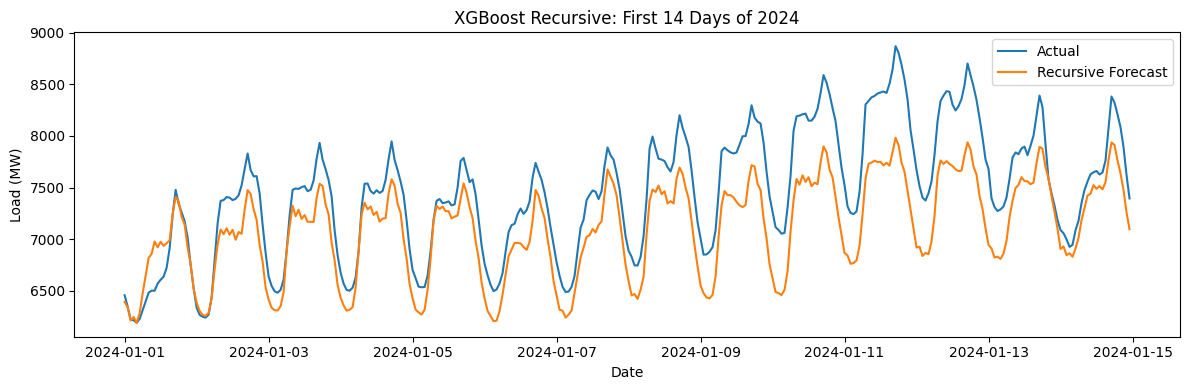

In [14]:
# ============================================
# 15. XGBoost Recursive
# ============================================
recursive_test = feat.loc["2024-01-01":"2024-12-31 23:00"].copy()
history_df = feat.loc[: "2023-12-31 23:00"].copy()
recursive_preds = []

for ts in recursive_test.index:
    row = recursive_test.loc[[ts]].copy()

    for L in [2, 3, 24, 48, 72, 168, 336]:
        lag_time = ts - pd.Timedelta(hours=L)
        if lag_time in history_df.index:
            row[f"lag_{L}"] = history_df.loc[lag_time, "y"]

    prev = history_df["y"].shift(1)
    row["roll_mean_24"] = prev.tail(24).mean()
    row["roll_mean_168"] = prev.tail(168).mean()
    row["roll_mean_336"] = prev.tail(336).mean()
    row["roll_mean_720"] = prev.tail(720).mean()
    row["roll_std_24"] = prev.tail(24).std()
    row["roll_std_168"] = prev.tail(168).std()

    X_row = row[XGB_FEATURES]
    yhat = float(xgb_direct_model.predict(X_row)[0])
    recursive_preds.append(yhat)

    new_row = row.copy()
    new_row["y"] = yhat
    new_row["TOTAL_LOAD"] = yhat
    history_df = pd.concat([history_df, new_row], axis=0)

xgb_recursive_pred = pd.Series(recursive_preds, index=recursive_test.index)
xgb_recursive_mae, xgb_recursive_rmse = print_metrics(recursive_test["y"], xgb_recursive_pred, label="XGBoost Recursive")

plt.figure(figsize=(12, 4))
plt.plot(recursive_test.index[:24 * 14], recursive_test["y"].iloc[:24 * 14], label="Actual")
plt.plot(recursive_test.index[:24 * 14], xgb_recursive_pred.iloc[:24 * 14], label="Recursive Forecast")
plt.title("XGBoost Recursive: First 14 Days of 2024")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


## XGBoost Model Interpretation:

From the results, I found that the XGBoost Direct model performs the best among all models, with an MAE of 70.16 MW (around 1.02% of the average load). This is a significant improvement compared to the other approaches, showing that the model is able to capture complex relationships between load, time-based patterns, and temperature using the engineered features.

During training, the validation performance improved steadily, and the RMSE decreased consistently, which suggests that the model is learning effectively without clear signs of overfitting. This indicates good generalization on the test data.

On the other hand, the XGBoost Recursive model performs worse, with a much higher MAE (~224.82 MW). This is mainly because errors accumulate over time, as each prediction depends on previous predicted values instead of actual observations.

This comparison shows that while recursive forecasting allows multi-step predictions, the direct approach is more stable and accurate in this case.

Overall, XGBoost provides the most reliable results in this project, as it captures both temporal patterns and the influence of external variables like temperature more effectively than the other models.


LSTM  RESULTS
Sequence shapes:
X_train_seq: (91656, 168, 22) | y_train_seq: (91656,)
X_val_seq  : (4416, 168, 22) | y_val_seq  : (4416,)
X_test_seq : (8784, 168, 22) | y_test_seq : (8784,)
Epoch 1/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 78s 90ms/step - loss: 0.0693 - val_loss: 0.0226 - learning_rate: 5.0000e-04
Epoch 2/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 135s 188ms/step - loss: 0.0254 - val_loss: 0.0172 - learning_rate: 5.0000e-04
Epoch 3/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 85s 119ms/step - loss: 0.0191 - val_loss: 0.0119 - learning_rate: 5.0000e-04
Epoch 4/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 80s 112ms/step - loss: 0.0161 - val_loss: 0.0123 - learning_rate: 5.0000e-04
Epoch 5/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 151s 211ms/step - loss: 0.0142 - val_loss: 0.0086 - learning_rate: 5.0000e-04
Epoch 6/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 198s 206ms/step - loss: 0.0130 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 7/50
717/717 ━━━━━━━━━━━━━━━━━━━━ 148s 206ms/step - loss: 0.0119 - val_loss: 0.0091 - learning_rate:

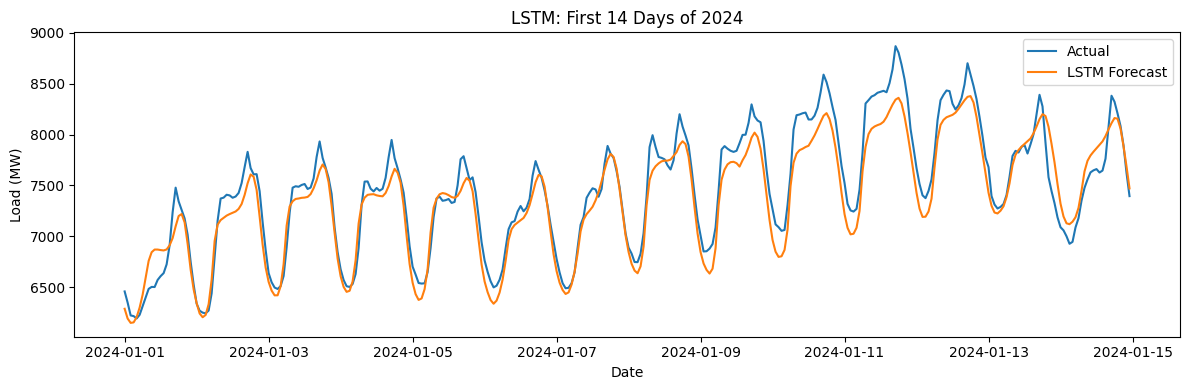

In [15]:
# ============================================
# 16. LSTM 
# ============================================
print("\nLSTM  RESULTS")

# Build LSTM v3 feature table
lstm_feat = df.copy()

# calendar
lstm_feat["hour_sin"]   = np.sin(2 * np.pi * lstm_feat.index.hour / 24)
lstm_feat["hour_cos"]   = np.cos(2 * np.pi * lstm_feat.index.hour / 24)
lstm_feat["dow_sin"]    = np.sin(2 * np.pi * lstm_feat.index.dayofweek / 7)
lstm_feat["dow_cos"]    = np.cos(2 * np.pi * lstm_feat.index.dayofweek / 7)
lstm_feat["month_sin"]  = np.sin(2 * np.pi * lstm_feat.index.month / 12)
lstm_feat["month_cos"]  = np.cos(2 * np.pi * lstm_feat.index.month / 12)
lstm_feat["is_weekend"] = (lstm_feat.index.dayofweek >= 5).astype(int)

# Alberta holidays
ab_holidays = holidays.Canada(prov="AB", years=range(2013, 2025))
holiday_dates = set(pd.to_datetime(list(ab_holidays.keys())).normalize())
lstm_feat["is_holiday"] = lstm_feat.index.normalize().isin(holiday_dates).astype(int)

# load lags
for L in [2, 3, 24, 48, 72, 168]:
    lstm_feat[f"lag_{L}"] = lstm_feat["TOTAL_LOAD"].shift(L)

# rolling load stats (past only)
load_s1 = lstm_feat["TOTAL_LOAD"].shift(1)
lstm_feat["roll_mean_24"]  = load_s1.rolling(24).mean()
lstm_feat["roll_mean_168"] = load_s1.rolling(168).mean()
lstm_feat["roll_std_24"]   = load_s1.rolling(24).std()
lstm_feat["roll_std_168"]  = load_s1.rolling(168).std()

# lagged temperature only
lstm_feat["temp_lag1"]         = lstm_feat["temperature"].shift(1)
lstm_feat["temp_lag24"]        = lstm_feat["temperature"].shift(24)
lstm_feat["temp_roll_mean_24"] = lstm_feat["temperature"].shift(1).rolling(24).mean()
lstm_feat["temp_roll_std_24"]  = lstm_feat["temperature"].shift(1).rolling(24).std()

# target
lstm_feat["y"] = lstm_feat["TOTAL_LOAD"]

lstm_cols = [
    "y",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "is_weekend", "is_holiday",
    "lag_2", "lag_3", "lag_24", "lag_48", "lag_72", "lag_168",
    "roll_mean_24", "roll_mean_168", "roll_std_24", "roll_std_168",
    "temp_lag1", "temp_lag24", "temp_roll_mean_24", "temp_roll_std_24"
]

lstm_feat = lstm_feat[lstm_cols].dropna()

# time-based split
lstm_train_df = lstm_feat.loc["2013-01-01":"2023-06-30 23:00"].copy()
lstm_val_df   = lstm_feat.loc["2023-07-01":"2023-12-31 23:00"].copy()
lstm_test_df  = lstm_feat.loc["2024-01-01":"2024-12-31 23:00"].copy()

lstm_feature_cols = [c for c in lstm_feat.columns if c != "y"]

X_train_raw = lstm_train_df[lstm_feature_cols]
y_train_raw = lstm_train_df["y"]

X_val_raw = lstm_val_df[lstm_feature_cols]
y_val_raw = lstm_val_df["y"]

X_test_raw = lstm_test_df[lstm_feature_cols]
y_test_raw = lstm_test_df["y"]

# scale on train only
mu_x = X_train_raw.mean()
sd_x = X_train_raw.std().replace(0, 1.0)

mu_y = float(y_train_raw.mean())
sd_y = float(y_train_raw.std()) if float(y_train_raw.std()) != 0 else 1.0

X_train_sc = (X_train_raw - mu_x) / sd_x
X_val_sc   = (X_val_raw - mu_x) / sd_x
X_test_sc  = (X_test_raw - mu_x) / sd_x

y_train_sc = (y_train_raw - mu_y) / sd_y
y_val_sc   = (y_val_raw - mu_y) / sd_y
y_test_sc  = (y_test_raw - mu_y) / sd_y

# sequence creation
lookback = 168

X_val_in  = pd.concat([X_train_sc.tail(lookback), X_val_sc], axis=0)
y_val_in  = pd.concat([y_train_sc.tail(lookback), y_val_sc], axis=0)

X_test_in = pd.concat([X_val_sc.tail(lookback), X_test_sc], axis=0)
y_test_in = pd.concat([y_val_sc.tail(lookback), y_test_sc], axis=0)

X_train_seq, y_train_seq = make_sequences(X_train_sc, y_train_sc, lookback)
X_val_seq,   y_val_seq   = make_sequences(X_val_in, y_val_in, lookback)
X_test_seq,  y_test_seq  = make_sequences(X_test_in, y_test_in, lookback)

print("Sequence shapes:")
print("X_train_seq:", X_train_seq.shape, "| y_train_seq:", y_train_seq.shape)
print("X_val_seq  :", X_val_seq.shape,   "| y_val_seq  :", y_val_seq.shape)
print("X_test_seq :", X_test_seq.shape,  "| y_test_seq :", y_test_seq.shape)

# model
tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
         dropout=0.2, recurrent_dropout=0.2),
    LSTM(16, dropout=0.2, recurrent_dropout=0.2),
    Dense(8, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=tf.keras.losses.Huber(delta=1.0)
)

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

rlr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=128,
    callbacks=[es, rlr],
    verbose=1
)

# predict and invert scaling
lstm_pred_sc = lstm_model.predict(X_test_seq).ravel()
lstm_pred = (lstm_pred_sc * sd_y) + mu_y
lstm_true = (y_test_seq * sd_y) + mu_y

lstm_test_index = lstm_test_df.index[:len(lstm_pred)]
lstm_pred_series = pd.Series(lstm_pred, index=lstm_test_index)
lstm_true_series = pd.Series(lstm_true, index=lstm_test_index)

lstm_mae, lstm_rmse = print_metrics(
    lstm_true_series,
    lstm_pred_series,
    label="LSTM"
)

plt.figure(figsize=(12, 4))
plt.plot(lstm_true_series.index[:24 * 14], lstm_true_series.iloc[:24 * 14], label="Actual")
plt.plot(lstm_pred_series.index[:24 * 14], lstm_pred_series.iloc[:24 * 14], label="LSTM Forecast")
plt.title("LSTM: First 14 Days of 2024")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## LSTM Model Interpretation:

From the results, I observed that the LSTM model performs well, with an MAE of 145.17 MW (around 2.10% of the average load). This shows that it is able to capture temporal patterns in electricity demand effectively.

Using a 168-hour lookback window allows the model to learn both daily and weekly patterns. During training, both training and validation loss decreased steadily, which suggests that the model is learning properly without clear overfitting.

From the forecast plot, the LSTM model follows the overall trend quite closely. However, it tends to slightly underestimate peak values and smooth out extreme fluctuations. This indicates that while it captures general patterns well, it is less effective at modeling sharp spikes compared to models like XGBoost.

Overall, the LSTM model performs better than the classical statistical models, but it still falls slightly behind XGBoost in terms of accuracy.

In [16]:
print("\nMODEL PERFORMANCE SUMMARY (Test: 2024)\n")

models = [
    ("SMA (168)", sma_mae, sma_rmse),
    ("CMA", cma_mae, cma_rmse),
    ("EWMA (24)", ewma_mae, ewma_rmse),
    ("AR(168)", ar_mae, ar_rmse),
    ("ARIMA(2,1,2)", arima_mae, arima_rmse),
    ("Manual SDIFF(24)+ARMA(1,0,1)", sarima_manual_mae, sarima_manual_rmse),
    ("Manual SDIFF(24)+Temp+ARMA(1,0,1)", sarimax_manual_mae, sarimax_manual_rmse),
    ("Prophet + Temp", prophet_mae, prophet_rmse),
    ("XGBoost Direct", xgb_direct_mae, xgb_direct_rmse),
    ("XGBoost Recursive", xgb_recursive_mae, xgb_recursive_rmse),
    ("LSTM ", lstm_mae, lstm_rmse),
]

# average load (for % metrics)
avg_load = float(y_test.mean())

# create dataframe
summary_df = pd.DataFrame(models, columns=["Model", "MAE", "RMSE"])

# percentage metrics
summary_df["MAE_%"] = (summary_df["MAE"] / avg_load) * 100
summary_df["RMSE_%"] = (summary_df["RMSE"] / avg_load) * 100

# sort by MAE (best first)
summary_df = summary_df.sort_values(by="MAE").reset_index(drop=True)

# ranking
summary_df["Rank"] = summary_df.index + 1

# reorder columns
summary_df = summary_df[["Rank", "Model", "MAE", "MAE_%", "RMSE", "RMSE_%"]]

summary_df_numeric = summary_df.copy()

summary_df_display = summary_df.copy()
summary_df_display["MAE"] = summary_df_display["MAE"].map(lambda x: f"{x:.2f}")
summary_df_display["RMSE"] = summary_df_display["RMSE"].map(lambda x: f"{x:.2f}")
summary_df_display["MAE_%"] = summary_df_display["MAE_%"].map(lambda x: f"{x:.2f}%")
summary_df_display["RMSE_%"] = summary_df_display["RMSE_%"].map(lambda x: f"{x:.2f}%")

print(summary_df_display.to_string(index=False))

summary_df_numeric.to_csv(MODEL_DIR / "final_model_comparison_2024.csv", index=False)


MODEL PERFORMANCE SUMMARY (Test: 2024)

 Rank                             Model     MAE  MAE_%    RMSE RMSE_%
    1                    XGBoost Direct   70.16  1.02%   91.79  1.33%
    2                             LSTM   145.17  2.10%  178.11  2.58%
    3                 XGBoost Recursive  224.82  3.26%  285.89  4.14%
    4                    Prophet + Temp  289.58  4.20%  380.97  5.52%
    5                         EWMA (24)  351.83  5.10%  412.23  5.98%
    6                         SMA (168)  389.92  5.65%  466.66  6.77%
    7                           AR(168)  439.76  6.38%  528.90  7.67%
    8 Manual SDIFF(24)+Temp+ARMA(1,0,1)  441.04  6.39%  568.87  8.25%
    9      Manual SDIFF(24)+ARMA(1,0,1)  442.27  6.41%  570.43  8.27%
   10                      ARIMA(2,1,2)  468.12  6.79%  592.12  8.58%
   11                               CMA 1333.47 19.33% 1452.15 21.05%


## Final Model Comparison and Conclusion:

From the overall comparison, I found that the XGBoost Direct model performs the best, achieving the lowest MAE (70.16 MW, about 1.02% of average load) and RMSE. This clearly shows that it is able to capture complex patterns in the data, including seasonality and the effect of temperature, more effectively than the other models.

The LSTM model ranks second, with good performance (around 2.10% MAE). It is able to learn temporal patterns over longer sequences, but it slightly underestimates peak values, which affects its accuracy compared to XGBoost.

The XGBoost Recursive model performs worse than the direct version, mainly because errors accumulate over time when predictions are fed back into the model. This makes it less stable for longer forecasts.

Prophet and the baseline models perform reasonably, but they show higher error and struggle with more complex or highly variable patterns. The classical statistical models (AR, ARIMA, SARIMA) perform the weakest overall, as they rely on linear assumptions and cannot fully capture the nonlinear behavior in electricity demand.

Overall, the results show that machine learning models—especially XGBoost—are more effective for this problem. With an error close to 1% of the average load, the model performs well enough to be useful in real-world applications like energy planning and demand forecasting.

In [17]:
# ============================================
# 18. Save final models
# ============================================
save_metadata = {
    "project": "Forecasting Alberta Electricity Load and Generation Mix",
    "train_start": "2013-01-01 00:00:00",
    "train_end": "2023-12-31 23:00:00",
    "test_start": "2024-01-01 00:00:00",
    "test_end": "2024-12-31 23:00:00",
    "target": "TOTAL_LOAD",
    "frequency": "Hourly",
    "random_seed": 42
}

# --- Metadata ---
with open(MODEL_DIR / "run_metadata.pkl", "wb") as f:
    pickle.dump(save_metadata, f)

# --- Classical models ---
with open(MODEL_DIR / "ar_168.pkl", "wb") as f:
    pickle.dump(ar_model, f)

with open(MODEL_DIR / "arima_212.pkl", "wb") as f:
    pickle.dump(arima_model, f)

with open(MODEL_DIR / "manual_sarima_sdiff24_arma101.pkl", "wb") as f:
    pickle.dump(
        {
            "model": manual_sarima_model,
            "seasonal_diff_lag": 24
        },
        f
    )

with open(MODEL_DIR / "manual_sarimax_sdiff24_temp_arma101.pkl", "wb") as f:
    pickle.dump(
        {
            "model": manual_sarimax_model,
            "seasonal_diff_lag": 24,
            "temp_sdiff_mean": mu,
            "temp_sdiff_std": sd
        },
        f
    )

# --- Prophet ---
with open(MODEL_DIR / "prophet_temp.pkl", "wb") as f:
    pickle.dump(
        {
            "model": prophet_model,
            "regressor": "temperature"
        },
        f
    )

# --- XGBoost ---
with open(MODEL_DIR / "xgb_direct.pkl", "wb") as f:
    pickle.dump(
        {
            "model": xgb_direct_model,
            "features": XGB_FEATURES,
            "params": xgb_direct_model.get_params()
        },
        f
    )

with open(MODEL_DIR / "xgb_recursive_base.pkl", "wb") as f:
    pickle.dump(
        {
            "model": xgb_direct_model,
            "features": XGB_FEATURES,
            "params": xgb_direct_model.get_params(),
            "recursive_reference_start": "2024-01-01 00:00:00"
        },
        f
    )

# --- LSTM v3 ---
lstm_model.save(MODEL_DIR / "lstm.keras")

with open(MODEL_DIR / "lstm_v3_scalers.pkl", "wb") as f:
    pickle.dump(
        {
            "feature_columns": lstm_feature_cols,
            "mu_x": mu_x,
            "sd_x": sd_x,
            "mu_y": mu_y,
            "sd_y": sd_y,
            "lookback": lookback
        },
        f
    )

# --- Baseline predictions ---
with open(MODEL_DIR / "baseline_predictions.pkl", "wb") as f:
    pickle.dump(
        {
            "sma_168": sma.loc[y_test.index],
            "ewma_24": ewma.loc[y_test.index],
            "cma": cma.loc[y_test.index]
        },
        f
    )

# --- Final comparison table ---
if "summary_df" in locals():
    summary_df.to_csv(MODEL_DIR / "final_model_comparison_2024.csv", index=False)

print(f"\nSaved all final model artifacts to: {MODEL_DIR.resolve()}")


Saved all final model artifacts to: C:\DAB\sem2\env\capstone\Dataset\final_models


## Limitations

While the models performed well, there are several limitations in this analysis.

First, hyperparameter tuning was limited, especially for XGBoost and LSTM. More systematic tuning (e.g., grid search or Bayesian optimization) could further improve performance.

Second, the models rely mainly on temperature as the only external variable. Other important factors such as economic activity, holidays beyond basic flags, or unexpected events were not included, which may affect accuracy.

Third, no rolling cross-validation was performed. The evaluation is based on a single train-test split (2024), which may not fully capture variability across different time periods.

Additionally, recursive forecasting showed error accumulation, indicating instability for long-term predictions.

Finally, while machine learning models achieved high accuracy, they are less interpretable compared to statistical models, which can be a limitation in real-world decision-making contexts.